model_experiment

In [1]:
! pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
! chmod 600 ~/.kaggle/kaggle.json

In [9]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:17<00:00, 16.7MB/s]



In [10]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [11]:
! pip install wandb --quiet

In [12]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data loading

In [13]:
df = pd.read_csv("icml_face_data.csv")
df.columns = df.columns.str.strip()
print(df.shape)
print(df["Usage"].value_counts())
df.head(3)

(35887, 3)
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...


In [14]:
EMOTION_LABELS = [
    "Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"
]

PIXELS_COL  = " pixels" if " pixels" in df.columns else "pixels"
EMOTION_COL = "emotion"
USAGE_COL   = "Usage"

class FERDataset(Dataset):
    """Wraps FER-2013 CSV rows into a PyTorch Dataset."""

    def __init__(self, df: pd.DataFrame, transform=None):
        self.labels = df[EMOTION_COL].values

        pixels = np.array(
            [np.fromstring(p, sep=" ", dtype=np.uint8) for p in df[PIXELS_COL]]
        ).reshape(-1, 48, 48)
        self.images = pixels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = img[np.newaxis, :, :]
        img = torch.from_numpy(img).float() / 255.0
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [15]:
MEAN, STD = 0.5071, 0.2555

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.Normalize(mean=[MEAN], std=[STD]),
])

val_transform = T.Compose([
    T.Normalize(mean=[MEAN], std=[STD]),
])

train_df = df[df[USAGE_COL] == "Training"].reset_index(drop=True)
val_df   = df[df[USAGE_COL] == "PublicTest"].reset_index(drop=True)

train_ds = FERDataset(train_df, transform=train_transform)
val_ds   = FERDataset(val_df,   transform=val_transform)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

Train samples: 28709 | Val samples: 3589


Batch shape: torch.Size([64, 1, 48, 48])  Label dtype: torch.int64


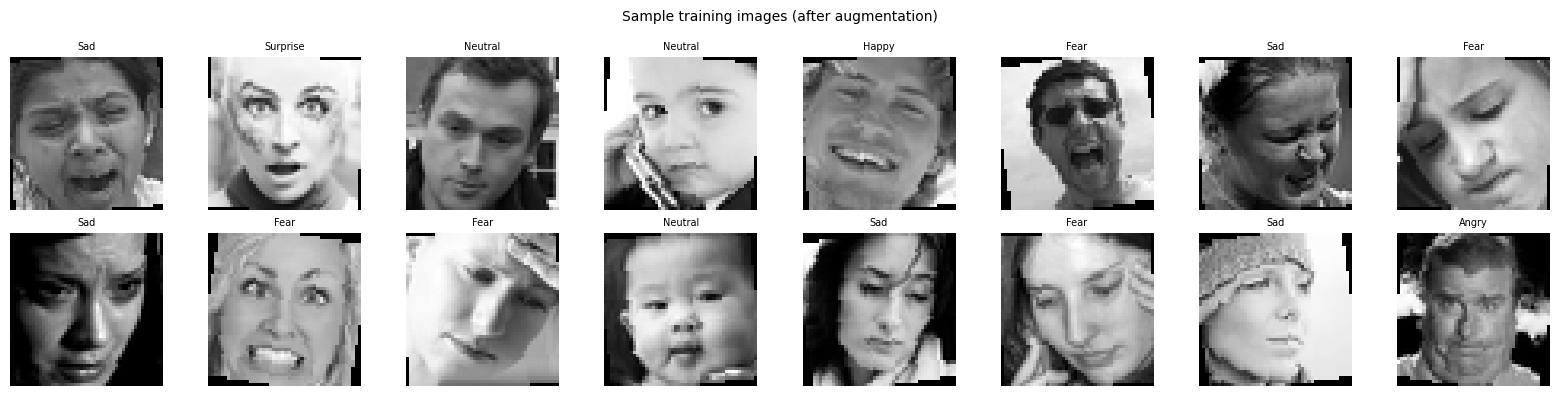

In [16]:
imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}  Label dtype: {lbls.dtype}")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap="gray")
    ax.set_title(EMOTION_LABELS[lbls[i].item()], fontsize=7)
    ax.axis("off")
plt.suptitle("Sample training images (after augmentation)", fontsize=10)
plt.tight_layout()
plt.show()

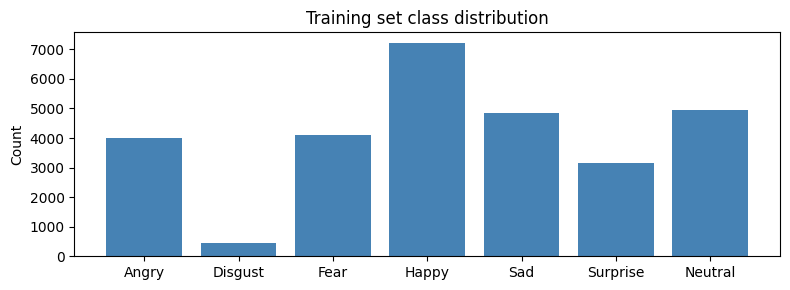

emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


In [17]:
counts = train_df[EMOTION_COL].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(EMOTION_LABELS, counts.values, color="steelblue")
ax.set_ylabel("Count")
ax.set_title("Training set class distribution")
plt.tight_layout()
plt.show()
print(counts)

## Model

In [18]:
class SimpleCNN(nn.Module):
    """Two-block CNN with GlobalAveragePooling head."""

    def __init__(self, num_classes: int = 7, dropout: float = 0.3):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),


            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = SimpleCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

Total parameters: 28,231


## Forward & backward pass checks


In [19]:

model.eval()
with torch.no_grad():
    dummy = torch.randn(8, 1, 48, 48).to(DEVICE)
    out   = model(dummy)

print(f"Output shape : {out.shape}")
print(f"Contains NaN : {torch.isnan(out).any().item()}")
print(f"Contains Inf : {torch.isinf(out).any().item()}")
assert out.shape == (8, 7), "Unexpected output shape!"
print("✓ Forward pass OK")

Output shape : torch.Size([8, 7])
Contains NaN : False
Contains Inf : False
✓ Forward pass OK


In [20]:
model.train()
criterion  = nn.CrossEntropyLoss()
_optimizer = optim.Adam(model.parameters(), lr=1e-3)

single_imgs, single_lbls = next(iter(train_loader))
single_imgs = single_imgs.to(DEVICE)
single_lbls = single_lbls.to(DEVICE)

print("Overfit on 1 batch for 50 steps:")
for step in range(50):
    _optimizer.zero_grad()
    loss = criterion(model(single_imgs), single_lbls)
    loss.backward()
    _optimizer.step()
    if (step + 1) % 10 == 0:
        print(f"  step {step+1:3d}  loss={loss.item():.4f}")

print("✓ Backward pass OK — loss decreasing as expected")

Overfit on 1 batch for 50 steps:
  step  10  loss=1.6801
  step  20  loss=1.5912
  step  30  loss=1.5160
  step  40  loss=1.5042
  step  50  loss=1.4143
✓ Backward pass OK — loss decreasing as expected


In [21]:
print(f"{'Parameter':<45} {'Shape':<20} {'Grad mean abs':>14}")
print("-" * 82)
dead_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.grad is None:
            dead_params.append(name)
            print(f"{name:<45} {str(tuple(param.shape)):<20} {'NO GRAD':>14}")
        else:
            mean_abs = param.grad.abs().mean().item()
            print(f"{name:<45} {str(tuple(param.shape)):<20} {mean_abs:>14.6f}")

if dead_params:
    print(f"\n⚠ Dead parameters (no gradient): {dead_params}")
else:
    print("\n✓ Gradient flow OK — all parameters receiving gradients")

model = SimpleCNN().to(DEVICE)

Parameter                                     Shape                 Grad mean abs
----------------------------------------------------------------------------------
features.0.weight                             (32, 1, 3, 3)              0.001889
features.0.bias                               (32,)                      0.000000
features.1.weight                             (32,)                      0.000944
features.1.bias                               (32,)                      0.001009
features.4.weight                             (64, 32, 3, 3)             0.000769
features.4.bias                               (64,)                      0.000000
features.5.weight                             (64,)                      0.002955
features.5.bias                               (64,)                      0.002290
classifier.2.weight                           (128, 64)                  0.001844
classifier.2.bias                             (128,)                     0.001431
classifier.4.we

## Training

In [22]:
EXPERIMENT_NAME = "exp1_simple_cnn"
CONFIG = dict(
    experiment   = EXPERIMENT_NAME,
    architecture = "SimpleCNN_2block_GAP",
    epochs       = 30,
    batch_size   = BATCH_SIZE,
    lr           = 1e-3,
    weight_decay = 1e-4,
    dropout      = 0.3,
    optimizer    = "Adam",
    scheduler    = "CosineAnnealingLR",
    seed         = SEED,
)

In [23]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["epochs"]
)


def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds      = logits.argmax(dim=1)
            correct    += (preds == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc" ].append(tr_acc)
    history["val_loss"  ].append(vl_loss)
    history["val_acc"   ].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_simple_cnn.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{CONFIG['epochs']} "
            f"| train loss {tr_loss:.4f}  acc {tr_acc:.4f} "
            f"| val loss {vl_loss:.4f}  acc {vl_acc:.4f}"
        )

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch   1/30 | train loss 1.7825  acc 0.2567 | val loss 1.7843  acc 0.2494
Epoch   5/30 | train loss 1.7449  acc 0.2849 | val loss 1.7321  acc 0.3009
Epoch  10/30 | train loss 1.7186  acc 0.3046 | val loss 1.7101  acc 0.3076
Epoch  15/30 | train loss 1.6929  acc 0.3178 | val loss 1.6623  acc 0.3338
Epoch  20/30 | train loss 1.6708  acc 0.3290 | val loss 1.6385  acc 0.3575
Epoch  25/30 | train loss 1.6571  acc 0.3352 | val loss 1.6273  acc 0.3642
Epoch  30/30 | train loss 1.6536  acc 0.3381 | val loss 1.6232  acc 0.3644

Best validation accuracy: 0.3644


## Analysis

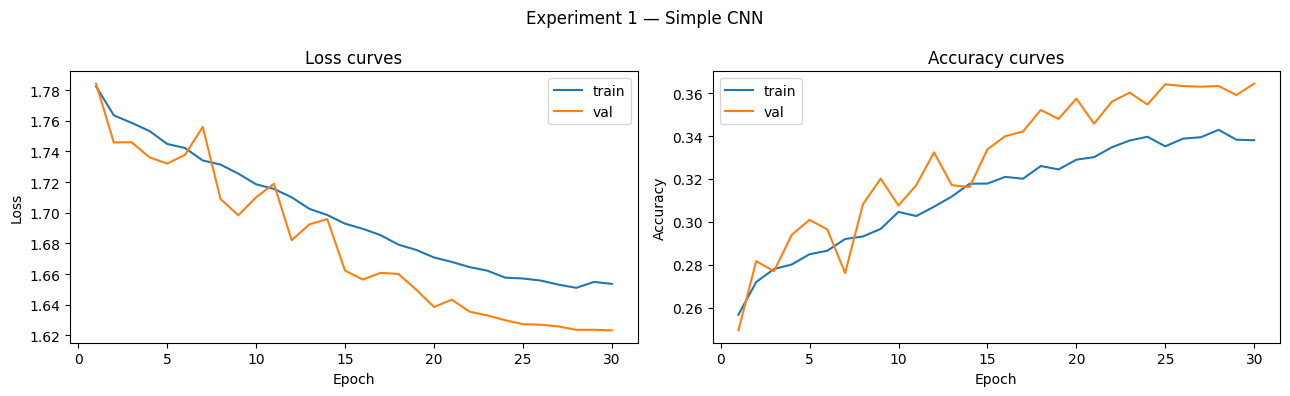

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, CONFIG["epochs"] + 1)

ax1.plot(epochs_range, history["train_loss"], label="train")
ax1.plot(epochs_range, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch");  ax1.set_ylabel("Loss")
ax1.set_title("Loss curves");  ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="train")
ax2.plot(epochs_range, history["val_acc"],   label="val")
ax2.set_xlabel("Epoch");  ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy curves");  ax2.legend()

plt.suptitle("Experiment 1 — Simple CNN", fontsize=12)
plt.tight_layout()
plt.show()

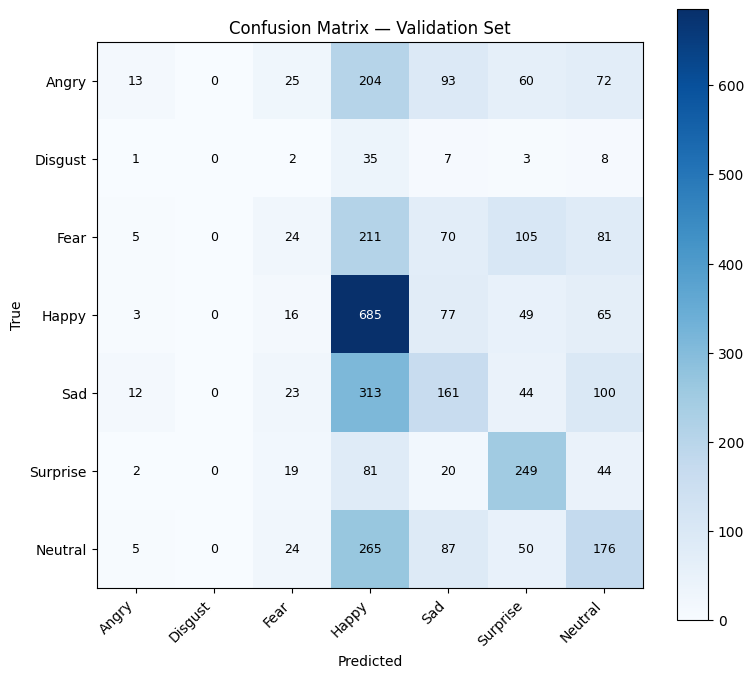


Classification report:
              precision    recall  f1-score   support

       Angry       0.32      0.03      0.05       467
     Disgust       0.00      0.00      0.00        56
        Fear       0.18      0.05      0.08       496
       Happy       0.38      0.77      0.51       895
         Sad       0.31      0.25      0.28       653
    Surprise       0.44      0.60      0.51       415
     Neutral       0.32      0.29      0.31       607

    accuracy                           0.36      3589
   macro avg       0.28      0.28      0.25      3589
weighted avg       0.32      0.36      0.31      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load("best_simple_cnn.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(7));  ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha="right")
ax.set_yticks(range(7));  ax.set_yticklabels(EMOTION_LABELS)
ax.set_xlabel("Predicted");  ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Validation Set")
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

In [26]:
final_train_acc = history["train_acc"][-1]
final_val_acc   = history["val_acc"][-1]
gap             = final_train_acc - final_val_acc

print("=" * 55)
print(f"  Final train accuracy : {final_train_acc:.4f}")
print(f"  Final val   accuracy : {final_val_acc:.4f}")
print(f"  Train–val gap        : {gap:.4f}")
print("=" * 55)

if final_train_acc < 0.50:
    diagnosis = "UNDERFITTING — model lacks capacity. Add more conv blocks / channels."
elif gap > 0.15:
    diagnosis = "OVERFITTING — large train-val gap. Try stronger regularisation (Dropout, augmentation, weight decay)."
elif gap < 0.05 and final_val_acc < 0.55:
    diagnosis = "UNDERFITTING with low variance — increase depth or width."
else:
    diagnosis = "Reasonable fit. Iterate to improve val accuracy further."

print(f"\n  Diagnosis: {diagnosis}")
print("\n  Next experiment: add a 3rd conv block (64→128 channels)")
print("  and compare metrics side-by-side on WandB.")

  Final train accuracy : 0.3381
  Final val   accuracy : 0.3644
  Train–val gap        : -0.0264

  Diagnosis: UNDERFITTING — model lacks capacity. Add more conv blocks / channels.

  Next experiment: add a 3rd conv block (64→128 channels)
  and compare metrics side-by-side on WandB.


# Wandb Tracking

In [27]:
! pip install wandb --quiet

In [28]:
import wandb

In [29]:
wandb.login()

wandb.init(
    project = "fer2013-experiments",
    name    = CONFIG["experiment"],
    config  = CONFIG,
    tags    = ["baseline", "simple-cnn"],
)
wandb.config.update({"total_params": sum(p.numel() for p in model.parameters())})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ntsuk22 (ntsuk22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [30]:
wandb.log({
    "epoch"              : epoch,
    "train/loss"         : tr_loss,
    "train/acc"          : tr_acc,
    "val/loss"           : vl_loss,
    "val/acc"            : vl_acc,
    "train_val/loss_gap" : abs(tr_loss - vl_loss),
    "train_val/acc_gap"  : abs(tr_acc  - vl_acc),
    "lr"                 : optimizer.param_groups[0]["lr"],
})

In [31]:
wandb.log({"learning_curves": wandb.Image(fig)})
plt.show()

In [32]:
wandb.log({"confusion_matrix": wandb.Image(fig)})

from sklearn.metrics import classification_report

report = classification_report(
    all_labels, all_preds,
    target_names=EMOTION_LABELS,
    output_dict=True,
)
table_data = [
    [
        emotion,
        round(report[emotion]["precision"], 3),
        round(report[emotion]["recall"], 3),
        round(report[emotion]["f1-score"], 3),
        int(report[emotion]["support"]),
    ]
    for emotion in EMOTION_LABELS
]
wandb.log({
    "per_class_metrics": wandb.Table(
        columns=["Emotion", "Precision", "Recall", "F1-score", "Support"],
        data=table_data,
    )
})

wandb.run.summary["best_val_acc"]    = best_val_acc
wandb.run.summary["final_train_acc"] = history["train_acc"][-1]
wandb.run.summary["final_val_acc"]   = history["val_acc"][-1]
wandb.run.summary["train_val_gap"]   = abs(history["train_acc"][-1] - history["val_acc"][-1])
wandb.run.summary["diagnosis"]       = diagnosis
wandb.finish()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


epoch,▁
lr,▁
train/acc,▁
train/loss,▁
train_val/acc_gap,▁
train_val/loss_gap,▁
val/acc,▁
val/loss,▁
best_val_acc,0.36445
diagnosis,UNDERFITTING — model...
epoch,30
